<a href="https://colab.research.google.com/github/ateachment/MoodleSearch/blob/main/moodleSearch_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lemmatisierung deutscher Sprache: 
https://nickyreinert.de/blog/2020/12/09/einfuehrung-in-stemming-und-lemmatisierung-deutscher-texte-mit-python/

Installation von HanoverTagger (wird :

In [1]:
# pip install HanTa 

In [2]:
import requests
import bs4
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

from HanTa import HanoverTagger as ht
hannover = ht.HanoverTagger('morphmodel_ger.pgz')

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity # We will use this later to decide how similar two sentences are

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\838235\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\838235\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\838235\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\838235\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [3]:
stop = nltk.corpus.stopwords.words('german')
# Add a few more stop words we would like to remove here
stop.append('daher')
stop.append('vieler')
stop.append('vielen')
stop.append('usw')
stop.append('bzw')
stop.append('etc')
stop.append('d.h.')
stop.append('u.a')
stop.append('z.b')
stop.append('--')
stop.append('-')
stop.append('.')  
stop.append('``')
stop.append("''")
stop

['aber',
 'alle',
 'allem',
 'allen',
 'aller',
 'alles',
 'als',
 'also',
 'am',
 'an',
 'ander',
 'andere',
 'anderem',
 'anderen',
 'anderer',
 'anderes',
 'anderm',
 'andern',
 'anderr',
 'anders',
 'auch',
 'auf',
 'aus',
 'bei',
 'bin',
 'bis',
 'bist',
 'da',
 'damit',
 'dann',
 'der',
 'den',
 'des',
 'dem',
 'die',
 'das',
 'dass',
 'daß',
 'derselbe',
 'derselben',
 'denselben',
 'desselben',
 'demselben',
 'dieselbe',
 'dieselben',
 'dasselbe',
 'dazu',
 'dein',
 'deine',
 'deinem',
 'deinen',
 'deiner',
 'deines',
 'denn',
 'derer',
 'dessen',
 'dich',
 'dir',
 'du',
 'dies',
 'diese',
 'diesem',
 'diesen',
 'dieser',
 'dieses',
 'doch',
 'dort',
 'durch',
 'ein',
 'eine',
 'einem',
 'einen',
 'einer',
 'eines',
 'einig',
 'einige',
 'einigem',
 'einigen',
 'einiger',
 'einiges',
 'einmal',
 'er',
 'ihn',
 'ihm',
 'es',
 'etwas',
 'euer',
 'eure',
 'eurem',
 'euren',
 'eurer',
 'eures',
 'für',
 'gegen',
 'gewesen',
 'hab',
 'habe',
 'haben',
 'hat',
 'hatte',
 'hatten',
 '

# Web Crawling

In [4]:
session = requests.Session()
session.headers['User-Agent'] = "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:130.0) Gecko/20100101 Firefox/130.0"

base_url = 'https://moodle.eick-at.de/course/view.php?id=21'  # URL of the Moodle Course "test"
r = session.get(base_url, allow_redirects=True, timeout=10)   # Make a GET request to the URL and store the response in r
r



<Response [200]>

In [5]:
#`r.text` contains the raw HTML returned when we made our GET request earlier. 
#`'html5lib'` tells BeautifulSoup that it is reading HTML information. 
soup = bs4.BeautifulSoup(r.text,'html5lib')
# script und style entfernen
for tag in soup(["script", "style"]):
    tag.decompose()
#print(soup.prettify()) # This will print the HTML in a more readable format. You can also just write `soup` to get the same result, but it is not as well formatted.



In [6]:
links = ["https://moodle.eick-at.de/course/view.php?id=21"]
rawTexts = ["Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial"]
rawText = "Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial"
shortTexts = [["Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial"]]
shortText = ["Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial"]

def scrapePage(link,linkText,shortText):
  short_txt = ""
  head = requests.head(link, allow_redirects=True)
  header = head.headers
  content_type = header.get('content-type')
  if content_type == "text/html; charset=utf-8":  # follow only html content
    r = session.get(link)                         # Seiten aufrufen
    #print(content_type, link)
    if r.ok:
      soup = bs4.BeautifulSoup(r.text,'html.parser')
      markUpPageContent=soup.find("div", {"id": "page-content"})
      if markUpPageContent is not None:  # link to source code etc.
        #for tag in markUpPageContent.select('form, navitem, gradingsummary'):      # get rid of forms
        #  tag.decompose()
        for tag in soup.select('span.nolink'):      # get rid of LaTeX formules
          tag.decompose()
        for tag in soup.select('div.mediaplugin'):  # get rid of Videos
          tag.decompose()
        for tag in soup.select('iframe'):           # get rid of iframes
          tag.decompose()
        for tag in soup.select('div.footer-content-popover'):  # get rid of Contents of question mark button
          tag.decompose()
        for tag in soup.select('div.drawer'):       # get rid of Contents of question mark button
          tag.decompose()

        for br in soup.select("br"):
            br.replace_with(" ")

        #print(markUpPageContent)
        paragraphs = markUpPageContent.find_all(['p','h1','h2','h3','h4','h5','h6'])   # Absätze
        if(paragraphs is not None):
          txt = ""
          short_txt = ""
          for paragraph in paragraphs:
            txt += paragraph.get_text() + ' '
            if(len(short_txt) < 50 ):
              short_txt += paragraph.get_text()
        rawTexts[-1] += ' ' + txt                   # add txt of page to last element of rawTexts
        shortTexts[-1] += [short_txt]               # add short_txt to last element of shortTexts

In [7]:
def cutText(txt): # gets list of words an extract the first 18 of them
  wordlength = 18
  wordlist = txt.split(' ')
  if len(wordlist) > wordlength:
    return ' '.join(wordlist[:wordlength]) + " ..."
  else:
    return txt

In [8]:
def scrapePage(link,linkText,shortText):
  print("SCRAPE_PAGE: ", linkText)
  short_txt = ""
  head = requests.head(link, allow_redirects=True, timeout=10)
  header = head.headers
  content_type = header.get('content-type')
  if content_type.__contains__("text/html"):        # follow only html content
    r = session.get(link)                           # Seiten aufrufen
    if r.ok:
      soup = bs4.BeautifulSoup(r.text,'html.parser')
      markUpPageContent=soup.find("div", {"id": "page-content"})
      if markUpPageContent is not None:  # link to source code etc.
        #for tag in markUpPageContent.select('form, navitem, gradingsummary'):      # get rid of forms
        #  tag.decompose()
        for tag in soup.select('span.nolink'):      # get rid of LaTeX formules
          tag.decompose()
        for tag in soup.select('div.mediaplugin'):  # get rid of Videos
          tag.decompose()
        for tag in soup.select('iframe'):           # get rid of iframes
          tag.decompose()
        for tag in soup.select('div.footer-content-popover'):  # get rid of Contents of question mark button
          tag.decompose()
        for tag in soup.select('div.drawer'):  # get rid of Contents of question mark button
          tag.decompose()

        for br in soup.select("br"):
            br.replace_with(" ")

        #print(markUpPageContent)
        paragraphs = markUpPageContent.find_all(['p','h1','h2','h3','h4','h5','h6'])   # Absätze
        if(paragraphs is not None):
          txt = ""
          short_txt = ""
          for paragraph in paragraphs:
            txt += paragraph.get_text() + ' '
            if(len(short_txt) < 50 ):
              short_txt += paragraph.get_text()
        rawTexts[-1] += ' ' + txt                                # add txt of page to last element of rawTexts
        shortTexts[-1] += [short_txt]         # add short_txt to last element of shortTexts

In [9]:
def crawlPageLinks(activity, sectionname, shortText, rawText):
    print("CRAWL_PAGE_LINKS", sectionname)
    global rawTexts, shortTexts, links
    link_page = activity.select_one("a.aalink")
    #print("CRAWL_PAGE_LINKS: ", link_page)
    shortTextAddition = []
    rawTextAddition = ""
    if link_page:
        url = link_page["href"]
        if "/mod/page/view.php" in url:

            linkText = link_page.select_one(".instancename").contents[0].strip()
            links.append(url)

            shortTexts.append(shortText + [linkText])
            shortTextAddition = [sectionname] + [linkText]
            rawTextAddition = ' ' + linkText
            rawTexts.append(rawText + rawTextAddition)                     # append text to list rawTexts

            print("LINK_PAGE=", url)
            print("LINK_TEXT=", linkText)

            scrapePage(url,linkText,shortText + [sectionname] + [linkText])
            
            #print("global shortTexts: ", shortTexts)
            #print("lokal shortText: ", shortText)
            #print("global rawTexts: ", rawTexts)
        else:
            print("Link_Page (ignored, no page link): ", url)   
    return shortTextAddition, rawTextAddition

In [10]:
def crawlSectionLinks(link_section, section, sectionname, shortText, rawText):
    print("\nCRAWL_SECTION_LINKS :", sectionname)
    global shortTexts, rawTexts

    #print("Parameter: ", sectionname, shortText)
    #print("CRAWL_SECTION_LINKS: ", link_section)
    print("LINK_SECTION=", link_section["href"])
    links.append(link_section["href"])                    # append link to list links
    
    summarytext = section.find('div', attrs={'class':'summarytext'})
    if (summarytext is not None):
        summarytext = summarytext.get_text(strip=True, separator=" ")
        print("SUMMARYTEXT=", summarytext)
        shortTextAddition = [sectionname] + [cutText(summarytext)]
        rawTextAddition = ' ' + sectionname + ' ' + summarytext
    else:
        shortTextAddition = [sectionname]
        rawTextAddition = ' ' + sectionname

    shortTexts.append(shortText + shortTextAddition)      # append shortText
    rawTexts.append(rawText + rawTextAddition)            # append text to list rawTexts
    #print("global shortTexts: ", shortTexts)
    #print("lokal shortText: ", shortText)
    print("global rawTexts: ", rawTexts)
    return shortTextAddition, rawTextAddition

In [11]:
def crawlCourse(link, shortText):
  
  r = session.get(link)
  #print(link)
  #print(r.status_code)
  if(r.ok):    # status_code 200
    soup = bs4.BeautifulSoup(r.text,'html5lib')
    #print(soup)
    for section in soup.select("ul[data-for='course_sectionlist'] > li.section"):

        # SECTION parser
        sectionname = section["data-sectionname"]

        link_section = section.select_one("h3.sectionname a")
        if link_section:
            shortTextAdditionSection, rawTextAdditionSection = crawlSectionLinks(link_section, section, sectionname, shortText, rawText)


        activitylist = section.select_one("ul[data-for='cmlist']")
        if not activitylist:
            continue
        

        for activity in activitylist.find_all("li", class_="activity", recursive=False):

            classes = activity.get("class", [])

            # normale Aktivität
            if "modtype_subsection" not in classes:
                shortTextAddition, rawTextAddition = crawlPageLinks(activity, sectionname, shortText + shortTextAdditionSection, rawText + rawTextAdditionSection)

            
            else:  # Subsection separat behandeln
                
                # SUBSECTION parser
                subsection = activity.select_one("li.section.delegated-section")
                if subsection:
                    subsection_name = subsection["data-sectionname"]

                    link_subsection = section.select_one("h4.sectionname a")
                    if link_subsection:
                        shortTextAdditionSubsection, rawTextAdditionSubsection = crawlSectionLinks(link_subsection, subsection, subsection_name, shortText + shortTextAdditionSection, rawText + rawTextAdditionSection)

                    for subactivity in subsection.select("li.activity"):
                        crawlPageLinks(subactivity, sectionname, shortText + shortTextAdditionSection + shortTextAdditionSubsection, rawText + rawTextAdditionSection + rawTextAdditionSubsection)

        

In [12]:
crawlCourse(base_url, shortText)


CRAWL_SECTION_LINKS : General
LINK_SECTION= https://moodle.eick-at.de/course/section.php?id=184
global rawTexts:  ['Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial', 'Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial General']
CRAWL_PAGE_LINKS General
Link_Page (ignored, no page link):  https://moodle.eick-at.de/mod/forum/view.php?id=1034
CRAWL_PAGE_LINKS General
Link_Page (ignored, no page link):  https://moodle.eick-at.de/mod/quiz/view.php?id=1035

CRAWL_SECTION_LINKS : New section
LINK_SECTION= https://moodle.eick-at.de/course/section.php?id=185
SUMMARYTEXT= description section spezial
global rawTexts:  ['Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial', 'Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial General', 'Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial New section description section spezial']
CRAWL_PAGE_LINKS New section
LINK_PAGE= https://moodle.eick-at.de/mod/page/view.php?id=122

In [13]:
def processText(txt):
  tokenized = nltk.tokenize.word_tokenize(txt)
  #print(tokenized)
  hannovered = [hannover.analyze(word)[0] for word in tokenized]
  #print(hannovered)
  processed = [w.lower() for w in hannovered if w not in stop]
  #print(processed)
  return processed


In [14]:
data = []    
i = 0
for rawText in rawTexts:
    #print(i, "RAW_TEXT=", rawText)
    print(i,"Link=", links[i], "\nRAW_TEXT=", rawText)
    print("SHORT_TEXT[i]=", shortTexts[i])
    processedText = processText(rawText)
    data.append((links[i], processedText))
    i += 1

print("DATA=", data)

0 Link= https://moodle.eick-at.de/course/view.php?id=21 
RAW_TEXT= Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial
SHORT_TEXT[i]= ['Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial']
1 Link= https://moodle.eick-at.de/course/section.php?id=184 
RAW_TEXT= Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial General
SHORT_TEXT[i]= ['Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial', 'General']
2 Link= https://moodle.eick-at.de/course/section.php?id=185 
RAW_TEXT= Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial New section description section spezial
SHORT_TEXT[i]= ['Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial', 'New section', 'description section spezial']
3 Link= https://moodle.eick-at.de/mod/page/view.php?id=1229 
RAW_TEXT= Das ist ein kleiner Test u.a. zum moodle crawlen - keyword spezial New section description section spezial Seite one spezial Das ist ein Test spezial 
SHORT

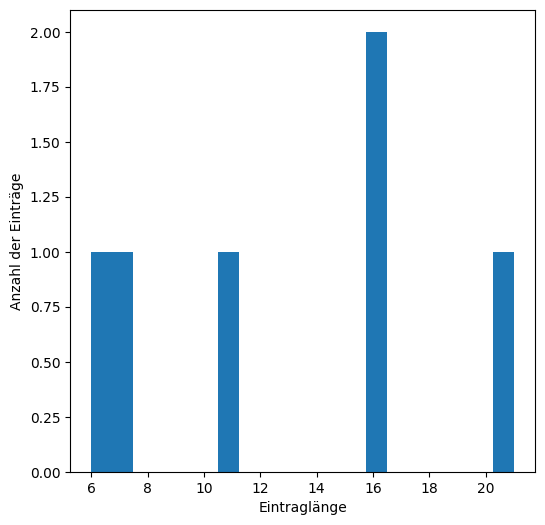

In [15]:
import matplotlib.pyplot as plt
def plot_hist(data):
    entry_lengths = [len(entry[1]) for entry in data]
    fig = plt.figure(figsize=(6, 6)) 
    plt.xlabel('Eintraglänge')
    plt.ylabel('Anzahl der Einträge')
    plt.hist(entry_lengths, bins=20)
    plt.show()
    return entry_lengths
entry_lengths = plot_hist(data)

Bag of words

In [16]:
# calculate frequency of words
def map_book(hash_map, tokens):
    if tokens is not None:
        for word in tokens:
            # Word Exist?
            if word in hash_map:
                hash_map[word] = hash_map[word] + 1
            else:
                hash_map[word] = 1

        return hash_map
    else:
        return None
        
def make_hash_map(data):  
    hash_map = {}
    for entry in data:
        hash_map = map_book(hash_map, entry[1])
    return hash_map


# define a function frequent_vocab with the following input: word_freq and max_features
def frequent_vocab(word_freq, max_features): 
    counter = 0  #initialize counter with the value zero
    vocab = []   # create an empty list called vocab
    # list words in the dictionary in descending order of frequency
    for key, value in sorted(word_freq.items(), key=lambda item: (item[1], item[0]), reverse=True): 
       #loop function to get the top (max_features) number of words
        if counter<max_features: 
            vocab.append(key)
            counter+=1
        else: break
    return vocab

In [17]:
hash_map = make_hash_map(data) #create hash map (words and frequency) from tokenized dataset

vocab=frequent_vocab(hash_map, 1000)  # adjust second Parameter
print(hash_map)
print(vocab)

{'klein': 6, 'test': 8, 'moodl': 6, 'crawl': 6, 'keyword': 6, 'spezial': 18, 'general': 1, 'new': 4, 'section': 8, 'description': 6, 'seite': 2, 'one': 1, 'subsection': 4, 'two': 1}
['spezial', 'test', 'section', 'moodl', 'klein', 'keyword', 'description', 'crawl', 'subsection', 'new', 'seite', 'two', 'one', 'general']


In [18]:
# define a function bagofwords with the following input: page and words
def bagofwords(data, vocab):
    # frequency word count
    bag = np.zeros(len(vocab)) #create a NumPy array made up of zeroes with size len(words)
    # loop through data and add value of 1 when token is present in the tweet
    for sw in data:
        for i,word in enumerate(vocab):
            if word == sw: 
                bag[i] += 1
                
    return np.array(bag) # return the bag of word for one page

In [19]:
test = ['subsection']
bagofwords(test, vocab)

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [20]:
# set up a NumPy array with the specified dimension to contain the bag of words
n_words = len(vocab)
n_docs = len(data)
bag_o = np.zeros([n_docs,n_words])
# use loop function to add new row for each data of page. 
for ii in range(n_docs): 
    #call out the previous function 'bagofwords'. see the inputs: sentence and words
    bag_o[ii,:] = bagofwords(data[ii][1], vocab) 

In [21]:
bag_o.shape

(6, 14)

Inverse document frequency

In [22]:
#initialize 2 variables representing the number of pages (numdocs) and the number of tokens/words (numwords)
numdocs, numwords = np.shape(bag_o)

#Changing into the tfidf formula as above
N = numdocs
term_frequency = np.empty(numwords)

#Count the number of documents the word appears in.
for word in range(numwords):
    term_frequency[word]=np.sum(bag_o[:,word]>0) 
print(term_frequency)
idf = np.log(N/term_frequency)
print(idf)

[6. 6. 4. 6. 6. 6. 4. 6. 2. 4. 2. 1. 1. 1.]
[0.         0.         0.40546511 0.         0.         0.
 0.40546511 0.         1.09861229 0.40546511 1.09861229 1.79175947
 1.79175947 1.79175947]


In [23]:
#initializs tfidf array
tfidf = np.empty([numdocs, numwords])

#loop through the pages, multiply term frequency (represented by bag of words) with idf
for doc in range(numdocs):
    tfidf[doc, :]=bag_o[doc, :]*idf

In [24]:
tfidf.shape

(6, 14)

In [25]:
print (tfidf)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         1.79175947]
 [0.         0.         0.81093022 0.         0.         0.
  0.40546511 0.         0.         0.40546511 0.         0.
  0.         0.        ]
 [0.         0.         0.81093022 0.         0.         0.
  0.40546511 0.         0.         0.40546511 1.09861229 0.
  1.79175947 0.        ]
 [0.         0.         0.81093022 0.         0.         0.
  0.81093022 0.         2.19722458 0.40546511 0.         0.
  0.         0.        ]
 [0.         0.         0.81093022 0.         0.         0.
  0.81093022 0.         2.19722458 0.40546511 1.09861229 1.79175947
  0.         0.        ]]


This data can be saved so that it does not have to be determined each time with web crawling and NLP (could be done as a task once a day).

In [26]:
filename = "tfidf.npy"   # file extension has to be "npy"
np.save(filename,tfidf)  # numpy provides file functions

The data can be loaded by this:

In [27]:
tfidf=np.load(filename)

In [28]:
# search string
search='subsection, two'

processed = processText(search)
print(processed)
search_vector = bagofwords(processed, vocab)
print(search_vector)

#calculate tfidf 
term_frequency = np.empty(numwords)

#Count the number of documents the search word appears in.
for word in range(numwords):
    term_frequency[word]=np.sum(search_vector[word]>0) 
print(term_frequency)

#initializs tfidf array
search_tfidf = np.empty([numwords])

#multiply term frequency (represented by bag of words) with idf
search_tfidf = term_frequency * idf

print(search_tfidf)

['subsection', ',', 'two']
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0.]
[0.         0.         0.         0.         0.         0.
 0.         0.         1.09861229 0.         0.         1.79175947
 0.         0.        ]


In [29]:
#comparision with search vector without tfidf
comparisons = cosine_similarity(tfidf, search_vector.reshape(1,-1))
print(comparisons)
#comparision with tfdif search vector => better results
comparisons = cosine_similarity(tfidf, search_tfidf.reshape(1,-1))
print(comparisons)

[[0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.61863402]
 [0.86129797]]
[[0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.45731169]
 [0.81713467]]


In [30]:
print("search word: ", search)
# best result
print("Best result:", data[comparisons.argmax()][0])

print("All results:")
for i, score in enumerate(comparisons):
    print(score, data[i][0])

search word:  subsection, two
Best result: https://moodle.eick-at.de/mod/page/view.php?id=1230
All results:
[0.] https://moodle.eick-at.de/course/view.php?id=21
[0.] https://moodle.eick-at.de/course/section.php?id=184
[0.] https://moodle.eick-at.de/course/section.php?id=185
[0.] https://moodle.eick-at.de/mod/page/view.php?id=1229
[0.45731169] https://moodle.eick-at.de/course/section.php?id=224
[0.81713467] https://moodle.eick-at.de/mod/page/view.php?id=1230
